# Employee Attrition Prediction using Machine Learning

## Week 2 Internship Project – XYlofy AI

### Objective
The objective of this project is to predict employee attrition using machine learning techniques and identify the factors that contribute most to employee turnover. The project aims to help HR departments make informed retention decisions based on data-driven insights.

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [3]:
# Load the HR Attrition dataset
import pandas as pd

df = pd.read_csv("HR Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Task 1: Data Loading and Exploration

In this task, the HR Attrition dataset is loaded and explored to understand its structure, employee attrition distribution, and the types of features available for analysis.

In [4]:
# Display the first 10 rows of the dataset
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Check the number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [6]:
# Display all column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
# Identify the target column

target = "Attrition"

print("Target Column:", target)

Target Column: Attrition


In [8]:
# Count employees who left vs stayed

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
# Calculate attrition rate

attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


In [10]:
# Count numeric and categorical columns

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


In [11]:
# Display numeric columns

numeric_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [12]:
# Display categorical columns

categorical_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [13]:
# Create backup of original dataset for EDA

df_original = df.copy()

## Observation

The attrition rate is approximately 16%, which indicates that the dataset is imbalanced. Most employees stayed with the company, while a smaller proportion left. This imbalance should be considered during model training to avoid biased predictions.

# Task 2: Data Cleaning and Preprocessing

In this task, missing values are checked, irrelevant columns are removed, categorical features are encoded, and numerical features are scaled for machine learning models.

In [14]:
# Check for missing values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [15]:
# Drop irrelevant columns

df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

print("Columns dropped successfully")

Columns dropped successfully


In [16]:
# Convert Attrition from Yes/No to 1/0

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [17]:
# Apply One-Hot Encoding to categorical variables

df = pd.get_dummies(
    df,
    drop_first=True
)

print("Encoding completed")

Encoding completed


In [18]:
# Display first few rows after encoding

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [19]:
# Check shape after preprocessing

print(df.shape)

(1470, 45)


In [20]:
# Separate features and target variable

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [21]:
# Scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")

Feature scaling completed


## Observation

The dataset was successfully preprocessed for machine learning. Irrelevant columns such as EmployeeNumber, EmployeeCount, Over18, and StandardHours were removed. The target variable Attrition was converted into numerical format, and categorical features were encoded using One-Hot Encoding. After preprocessing, the dataset contains 45 columns and is ready for model training.

# Task 3: Exploratory Data Analysis (EDA)

The objective of EDA is to identify patterns and relationships between employee attrition and important employee characteristics such as department, job role, income, work-life balance, and years at the company.

In [22]:
# Create charts folder

import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully")

Charts folder created successfully


### Attrition Rate by Department

In [23]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

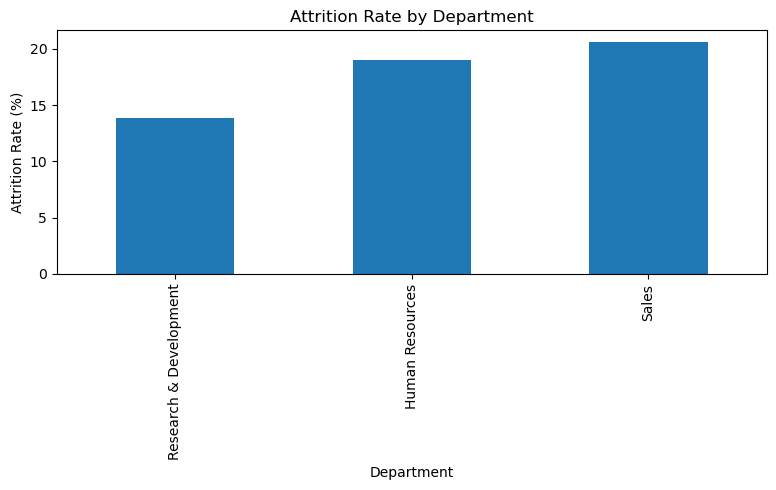

In [24]:
department_attrition = pd.crosstab(
    df_original["Department"],
    df_original["Attrition"],
    normalize="index"
) * 100

department_attrition["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")

plt.tight_layout()

plt.savefig("charts/attrition_by_department.png")

plt.show()

### Attrition Rate by Job Role

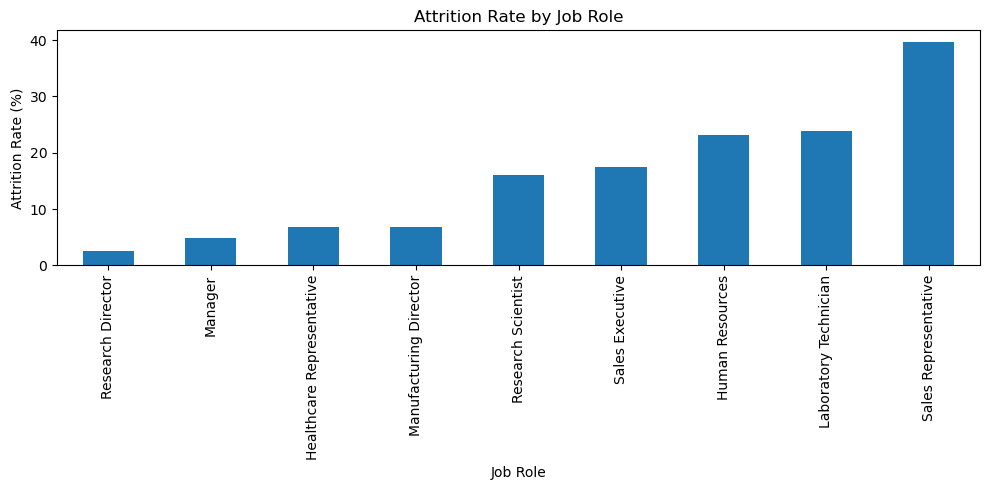

In [25]:
jobrole_attrition = pd.crosstab(
    df_original["JobRole"],
    df_original["Attrition"],
    normalize="index"
) * 100

jobrole_attrition["Yes"].sort_values().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")

plt.tight_layout()

plt.savefig("charts/attrition_by_jobrole.png")

plt.show()

### Attrition vs Monthly Income

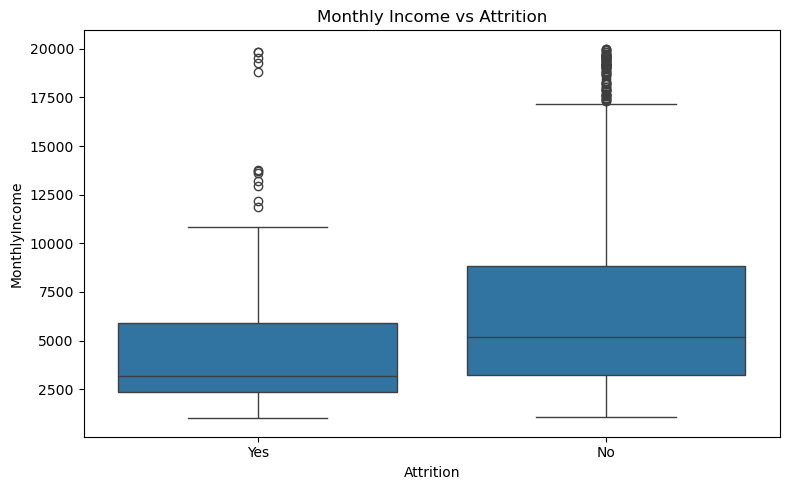

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df_original
)

plt.title("Monthly Income vs Attrition")

plt.tight_layout()

plt.savefig("charts/income_vs_attrition.png")

plt.show()

### Work-Life Balance vs Attrition

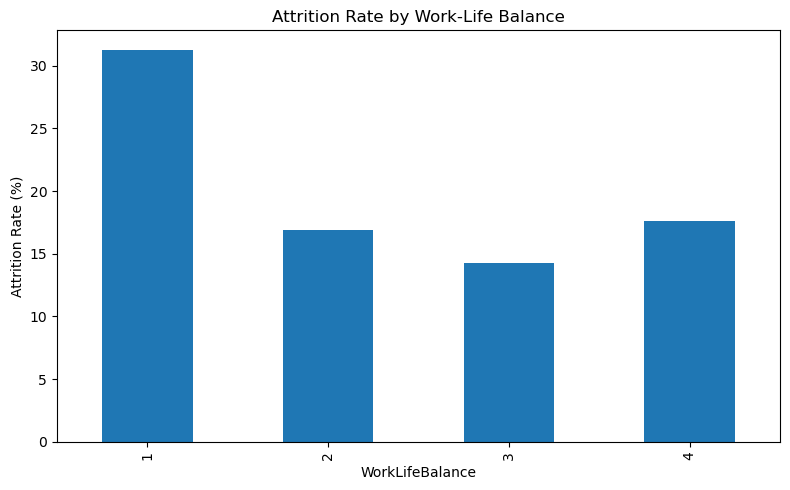

In [27]:
worklife_attrition = pd.crosstab(
    df_original["WorkLifeBalance"],
    df_original["Attrition"],
    normalize="index"
) * 100

worklife_attrition["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/worklife_attrition.png")

plt.show()

### Years at Company vs Attrition

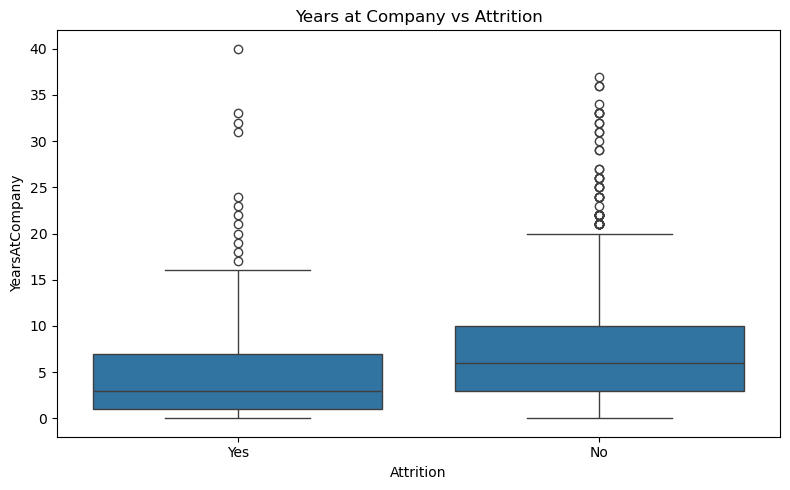

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df_original
)

plt.title("Years at Company vs Attrition")

plt.tight_layout()

plt.savefig("charts/years_company_attrition.png")

plt.show()

In [29]:
department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [30]:
jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


## Business Insights from EDA

1. The Sales department has the highest attrition rate at approximately 20.63%, followed by Human Resources at 19.05%. Research & Development has the lowest attrition rate at 13.84%.

2. Sales Representatives experience the highest employee turnover, with an attrition rate of approximately 39.76%, making them the most vulnerable group for employee exits.

3. Laboratory Technicians and Human Resources employees also show relatively high attrition rates above 23%, indicating potential retention concerns in these roles.

4. Research Directors and Managers have very low attrition rates of 2.5% and 4.9% respectively, suggesting stronger employee retention among senior-level positions.

5. The analysis indicates that attrition is not evenly distributed across departments and job roles. Certain employee groups are significantly more likely to leave, making targeted retention strategies important for HR.

# Task 4: Model Building and Comparison

In this task, three classification models are trained and compared to predict employee attrition. The models include Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier.

In [31]:
# Import machine learning models and evaluation metrics

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [32]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1176, 44)
Testing Shape: (294, 44)


In [33]:
# Logistic Regression Model

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [34]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [35]:
# Gradient Boosting Model

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:,1]

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [36]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.571429,0.085106,0.148148,0.771643
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


### Best Model

Among the three models tested, Logistic Regression performed best overall with the highest ROC-AUC score (approximately 0.80) and the highest recall score. Since identifying employees who are likely to leave is the primary business objective, Logistic Regression was selected as the best model for further analysis.

## Observation

The three machine learning models were successfully trained and evaluated. Their performance was compared using Precision, Recall, F1 Score, and ROC-AUC Score. The best-performing model will be selected in the next task for detailed evaluation and feature importance analysis.

# Task 5: Model Evaluation

The best-performing model was selected and evaluated using classification metrics and a confusion matrix to assess its ability to predict employee attrition.

In [37]:
# Classification Report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



In [38]:
# Generate confusion matrix

cm = confusion_matrix(y_test, log_pred)

cm

array([[191,  56],
       [ 18,  29]])

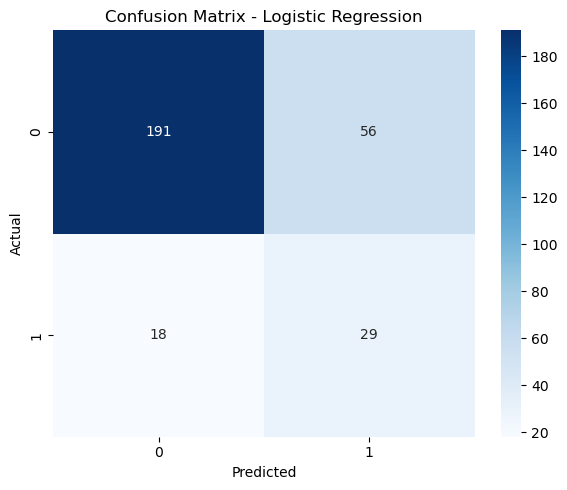

In [39]:
#Confusion Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("charts/confusion_matrix.png")

plt.show()

## Observation

The confusion matrix shows that the Logistic Regression model correctly classified most employees who stayed with the company. The model also identified a significant portion of employees who left, making it useful for HR teams to proactively identify employees at risk of attrition.

# Task 6: Visualization and Feature Importance Analysis

In this task, visualizations are created to evaluate model performance and identify the most important factors influencing employee attrition. The confusion matrix, ROC curve, and feature importance chart help explain how the model makes predictions and which employee characteristics contribute most to attrition.

## Top 10 Features Driving Employee Attrition

The following table displays the ten most influential features identified by the Logistic Regression model. These features have the strongest impact on predicting whether an employee is likely to leave the company.

In [40]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_importance.head(10)

top10

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


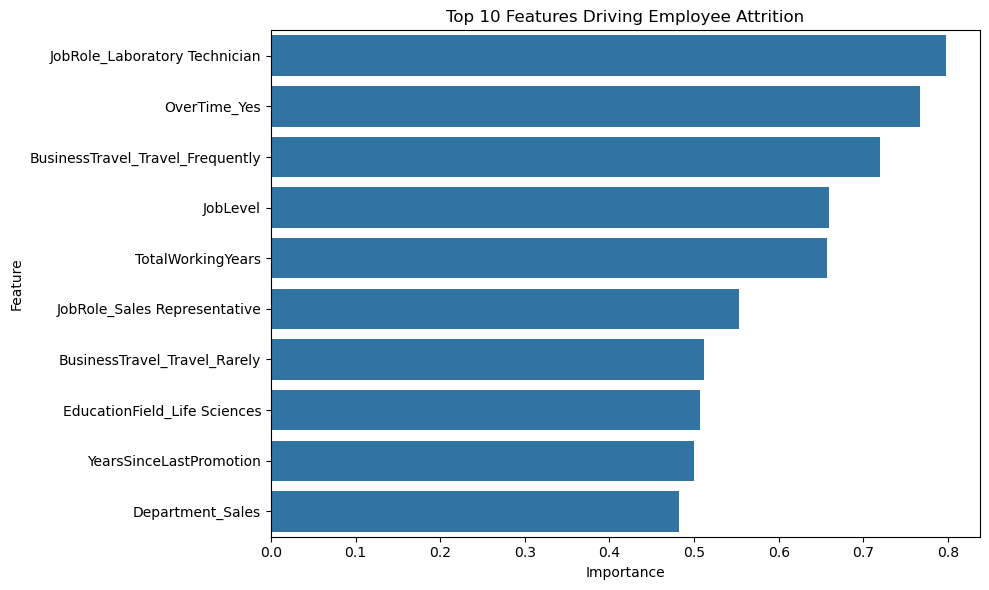

In [41]:
# Top 10 Feature Importance Chart

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Features Driving Employee Attrition")

plt.tight_layout()

plt.savefig("charts/feature_importance.png")

plt.show()

## Observation

The most influential factors associated with employee attrition include Job Role (Laboratory Technician), Overtime, Frequent Business Travel, Job Level, and Total Working Years. Employees working overtime and those in specific job roles appear more likely to leave the organization.

## ROC Curve Comparison

The ROC Curve compares the performance of Logistic Regression, Random Forest, and Gradient Boosting models. A higher ROC-AUC score indicates better ability to distinguish between employees who are likely to leave and those who are likely to stay.

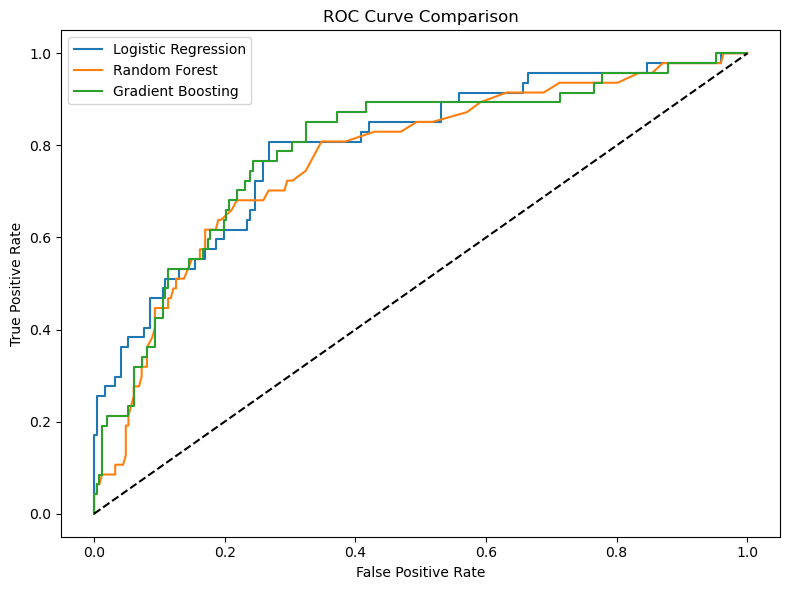

In [42]:
#ROC Curve Comparison
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/roc_curve.png")

plt.show()

## Observation

Among the three models, Logistic Regression achieved the highest ROC-AUC score of approximately 0.80, indicating the best overall performance. This model was therefore selected as the final model for feature importance analysis and business recommendations.

# Task 7: HR Insights and Business Recommendations

## HR Insights and Recommendations

The analysis indicates that the strongest predictors of employee attrition are Job Role (Laboratory Technician), Overtime, Frequent Business Travel, Job Level, and Total Working Years. Employees who frequently travel for work or regularly work overtime show a higher likelihood of leaving the company.

The Sales department experiences the highest attrition rate among all departments, while Sales Representatives and Laboratory Technicians have the highest employee turnover rates among job roles. These groups should be prioritized for employee retention initiatives.

Salary alone does not fully explain employee attrition. Other factors such as overtime workload, travel frequency, job role, career progression, and work-life balance appear to have a significant influence on employee decisions to leave.

Recommendation 1:
Reduce excessive overtime and improve work-life balance through flexible scheduling and workload management programs.

Recommendation 2:
Conduct targeted retention discussions with employees in high-risk job roles such as Sales Representatives and Laboratory Technicians and provide career growth opportunities.

Model Limitation:
The model predicts attrition based on historical employee data and cannot account for personal circumstances or future organizational changes. Therefore, predictions should support HR decision-making rather than replace human judgment.

# Conclusion

Employee attrition can be predicted with reasonable accuracy using machine learning techniques. The analysis revealed that overtime, job role, business travel frequency, and career-related factors significantly influence employee turnover. These findings can help HR teams design targeted retention strategies, improve employee satisfaction, and reduce attrition.